# 1.4 Solving Linear and Nonlinear Equations

In [1]:
using LinearSolve
using NonlinearSolve
using CairoMakie

Solving a single or a system of linear and nonlinear set of equations is related to many engineering applications. 
This notebook serves as a revision to techniques that you would have been taught in other parts of your degree program so far.  



### Linear Equations

#### Example 1.4.1

Example of linear set of equations is given in the circuit diagram below

![Local image](../figures/01p04Fig01.png)

Applying Kirchoff’s voltage law gives

$R_1i_1+R_2i_2=V_1$

$-R_2i_2+R_3i_3+R_4i_4=0$

$R_4i_4-R_5i_5=V_2$

We also know that

$i_1-i_2-i_3=0$

$i_3-i_4-i_5=0$

We would like to solve for the unknowns $i_1$, $i_2$, $i_3$, $i_4$ and $i_5$.  We can put the equations in matrix form as

$$\begin{bmatrix}
   {R_1} & {R_2} & {0}    & {0} & {0}       \\
   {0} & -{R_2} & {R_3}    & {R_4}  & {0}     \\
   {0} & {0} & {0}  & {R_4}  & -{R_5}   \\
   {1} & {-1} & {-1} & {0}  & {0}  \\
{0} & {0} & {1} & {-1}  & {-1}  \\
\end{bmatrix}\begin{Bmatrix}
i_1\\
i_2\\
i_3\\
i_4\\
i_5\\
\end{Bmatrix}= \begin{Bmatrix}
V_1\\
0\\
V_2\\
0\\
0\\
\end{Bmatrix}$$

This is a linear system of 5 equations.  In general, we can write this equation as

$[A]\{x\}=\{C\}$

where $[A]$ and $\{C\}$ are known and you want to find the vector $\{x\}$.  In this course, I can denote vector either with an arrowhead on top of the variable, $\vec{x}$ or with curly brackets $\{x\}$.  A matrix is denoted with square brackets $[A]$ or bold letter $\mathbf{A}$.  I can sometimes write the above equation as

$\mathbf{A}\vec{x}=\vec{C}$

In [2]:
R₁=5
R₂=150
R₃=100
R₄=250
R₅=200

V₁=100.0
V₂=50.0

A=[R₁ R₂ 0 0 0;
  0 -R₂ R₃ R₄ 0;
  0 0 0 R₄ -R₅;
  1 -1 -1 0 0;
  0 0 1 -1 -1]

C₁=[V₁, 0, V₂, 0, 0] #C1 is a (5x1) column vector
C₂=[V₁  0  V₂  0  0] #C2 is a (1x5) row matrix


1×5 Matrix{Float64}:
 100.0  0.0  50.0  0.0  0.0

To solve this set of equations, you can use the \ operator.  This is the "lazy" way and can be quite slow once you get to more complex and bigger set of equations.  The @time macro before the command just prints out the time it takes to execute the command

In [3]:
@time i=A\C₁

  0.180969 seconds (633.38 k allocations: 32.603 MiB, 99.91% compilation time)


5-element Vector{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

In [4]:
A\C₂'

5×1 Matrix{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

You can also solve $[A]\{x\}=\{C\}$ using `LinearSolve` library.  You will find that `LinearSolve`  is usually faster than the \ operator, especially for larger system.  

In [5]:
# Define the linear problem
prob = LinearProblem(A,C₁)

# Solve the problem using defaults
@time sol = solve(prob)

  1.168989 seconds (5.60 M allocations: 291.600 MiB, 3.63% gc time, 99.98% compilation time)


retcode: Success
u: 5-element Vector{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

In [6]:
i=sol.u

5-element Vector{Float64}:
 0.9543568464730301
 0.6348547717842323
 0.31950207468879666
 0.25311203319502074
 0.0663900414937759

The field *u* inside the contains the solution.  sol contains other fields as well.  For example the *retcode* field returns whether the `solve()` successfully finds a solution or not.

In [7]:
sol.retcode

ReturnCode.Success = 1

---
**Class Demo 01:**  Write a Julia program that solves for $i_5$ for $V_1\in[50,100]$.  Plot $i_5$ vs $V_1$ to visualise how $i_5$ changes with $V_1$.

---

### Nonlinear Equations

Solving nonlinear equations are more difficult.  It usually requires the use of iterative schemes.  One of the most popular scheme is the Newton-Raphson scheme.  There are a few ways of thinking about the Newton-Raphson scheme.  One is the `graphical' way which is shown below

<figure>
  <img src="../figures/01p04Fig02.png" alt="Description of the figure" width="40%">
  <figcaption>Figure 1: Illustrating Newton-Raphson scheme.</figcaption>
</figure>

Suppose we want to find $x$ such that $f(x)=0$.  The value(s) of $x$ such that is makes the function $f(x)=0$ is (are) called the root(s) of the function $f$. From geometry, it is easy to see that $x_{i+1}$ is closer to the root of $f(x)$ than $x_{i}$.  From trigonometry, 

$\frac{df}{dx}(x_i)=\frac{f(x_i)}{x_i-x_{i+1}}$

Therefore

$x_{i+1}=x_i-\frac{f(x_i)}{\frac{df}{dx}(x_i)}$

Alternatively, one can derive this same formula using the Taylor series

$ f(x_{i+1})=f(x_i)+f'(x_i)(x_{i+1}-x_i)+\frac{f''(x_i) }{2!}(x_{i+1}-x_i)^{2}+\frac{f^{(''')}(x_i) }{3!}(x_{i+1}-x_i)^{3}+\cdots$

Let's truncate this Taylor series to the 2nd order

$f(x_{i+1})=f(x_i)+f'(x_i)(x_{i+1}-x_i)$

we want to find $x_i$ such that $f(x_{i+1})=0$.  So setting $f(x_{i+1})=0$ in the equation above gives

$f(x_i)+f'(x_i)(x_{i+1}-x_i)=0$

$x_{i+1}=x_i-f(x_i)/f'(x_i)$

#### Example 1.4.2

Let's now try this for the problem that I introduced in Notebook 1.1.  We want to find $r$ such that we minimize 

$A(r)=2\pi r^2+\frac{2}{r}$.

So we want to find $r$ such that 

$dA(r)/dr=4\pi r-\frac{2}{r^2}=0$.

So for this problem

$f(x)=4\pi x-\frac{2}{x^2}$

$df/dx(x)=4\pi +\frac{4}{x^3}$

Let's plot this function and remind ourselves how it looks like

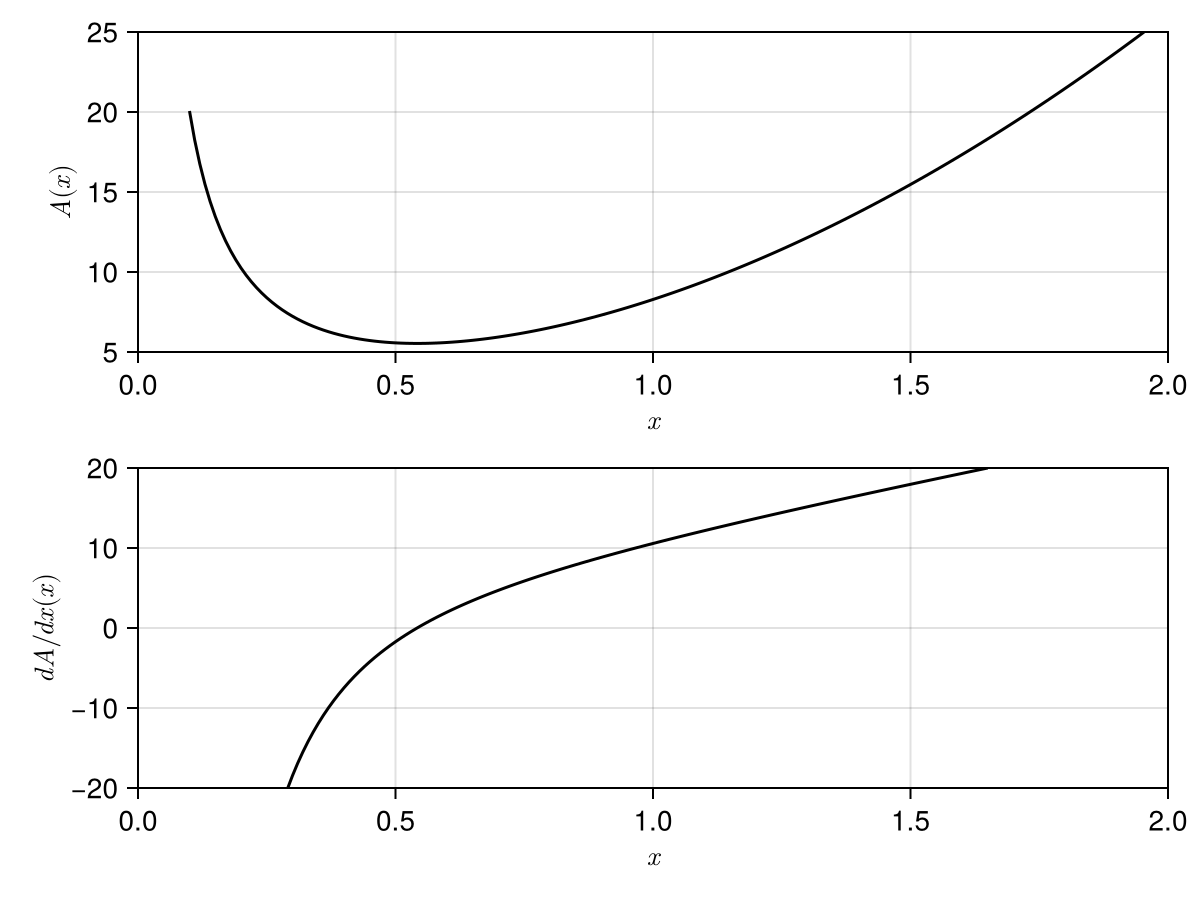

CairoMakie.Screen{IMAGE}


In [8]:
Area(x)=2π*x^2+2/x
f(x)=4π*x-2/x^2
dfdx(x)=4π+4/x^3

xplot=0.1:0.01:2
fig = Figure() #set up a figure
ax1 = Axis(fig[1, 1], xlabel = L"x", ylabel = L"A(x)",limits=(0,2,5,25)) #Define axis in the figure
ax2 = Axis(fig[2, 1], xlabel = L"x", ylabel = L"dA/dx(x)",limits=(0,2,-20,20)) #Define axis in the figure
lines!(ax1,xplot,Area.(xplot);color=:black) #Plot A(x) vs x
lines!(ax2,xplot,f.(xplot);color=:black) #Plot dA/dx(x) vs x
save("../figures/01p04SolvingLinearAndNonlinearEquations02.svg", fig)
display(fig) #show the figure

Code to use Newton-Raphson Method to solve for $x$ where $f(x)=0$

In [9]:
x=1.0 #initial guess
for i=1:10
    x=x-f(x)/dfdx(x)
    println(x)
end

0.3621795105078358
0.4727153376004709
0.5323948682518493
0.5417564911696957
0.5419260170637374
0.5419260701392838
0.5419260701392891
0.5419260701392891
0.5419260701392891
0.5419260701392891


For this simple equation, you can find the root exactly to be
$x=\sqrt[3]{\frac{1}{2\pi}}$

In [10]:
(1/(2π))^(1/3)

0.5419260701392891

You can also use the `NonlinearSolve()` library to solve this equation

In [11]:
x0=1.0 #initial guess
p=[] #no parameters
prob = NonlinearProblem((x,p)->f(x),x0,p)
sol = NonlinearSolve.solve(prob)

┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase /Users/asho/.julia/packages/SciMLBase/7YrMQ/src/performance_warnings.jl:32


retcode: Success
u: 0.5419260701392838

---

**Class  Demo 02:**  Write a Julia Program that uses the Newton-Raphson method to find $x$ such that

$5x^2=8+x\cos(x)$

---

---

Sometimes, we need to solve a set of (more than 1) nonlinear equations.    I will illustrate with with the system of two nonlinear equations

$
\begin{align}
  u(x,y) = 0 \\
  v(x,y) = 0 
\end{align}$

Performing Taylor series expansion gives

\begin{align}

u(x_{i + 1} ,y_{i + 1} ,z_{i + 1} ) &\approx u(x_i ,y_i ,z_i )
                                     +  u_x (x_i ,y_i ,z_i )(x_{i + 1}  - x_i ) \\
                    & + u_y (x_i ,y_i ,z_i )(y_{i + 1}  - y_i ) =0 \\
v(x_{i + 1} ,y_{i + 1} ,z_{i + 1} ) & \approx   v(x_i ,y_i ,z_i )
                    + v_x (x_i ,y_i ,z_i )(x_{i + 1}  - x_i ) \\
                    & +  v_y (x_i ,y_i ,z_i )(y_{i + 1}  - y_i ) =0\\
\end{align}

where

\begin{align}
u_x  &= \frac{{\partial u}}{{\partial x}},{\rm     }u_y  = \frac{{\partial u}}{{\partial y}},{\rm    }\\
v_x  &= \frac{{\partial v}}{{\partial x}},{\rm     }v_y  = \frac{{\partial v}}{{\partial y}},{\rm    }\end{align}

We can put the above equations in Matrix form as

$\begin{bmatrix}
   {u_x } & {u_y }   \\
   {v_x } & {v_y }   \\
\end{bmatrix} $
$\begin{Bmatrix}
   {x_{i + 1}  - x_i }  \\
   {y_{i + 1}  - y_i }  
\end{Bmatrix} 
=$
$-\begin{Bmatrix}
   u  \\
   v 
\end{Bmatrix} $

So now to find $x_{i + 1}$ and $y_{i + 1}$, you need to solve a system of linear equations

#### Example 1.4.3

I will illustrate with with the system of two nonlinear equations





\begin{align}
y&= x^2 + 1\\
y&=3\cos(x)
\end{align}

\begin{align}
u(x,y)&= x^2 -y+ 1=0\\
v(x,y)&=3\cos(x)-y=0
\end{align}

Let's plot the function to see how they look like

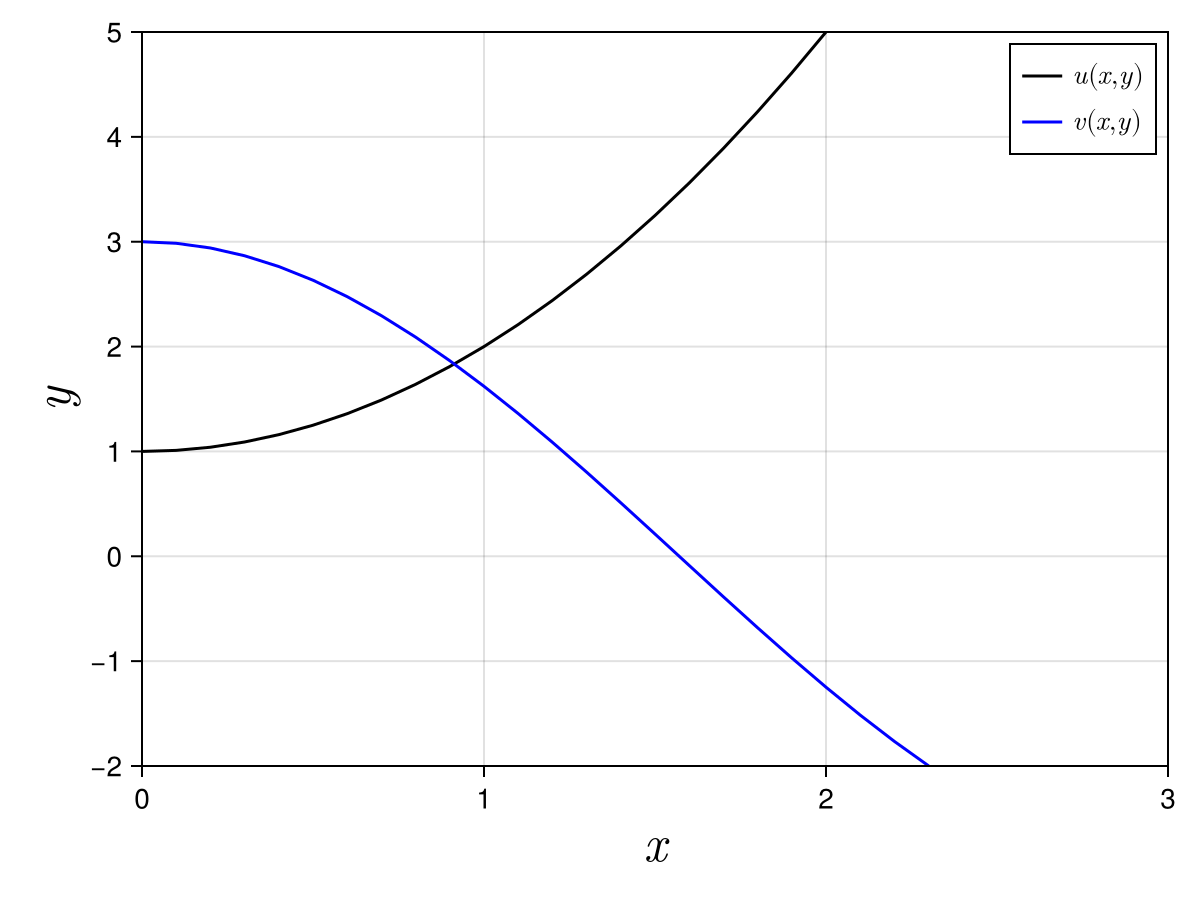

CairoMakie.Screen{IMAGE}


In [12]:
x₁=0:0.1:3
y₁=x₁.^2 .+1
y₂=3*cos.(x₁);

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    limits=(0,3,-2.0,5.0),
    xlabelsize = 25, 
    ylabelsize = 25)
lines!(ax,x₁,y₁;color=:black,label=L"u(x,y)") 
lines!(ax,x₁,y₂;color=:blue,label=L"v(x,y)")
axislegend(ax, position = :rt) # Options: :rt, :lt, :lb, :rb, etc.
save("../figures/01p04SolvingLinearAndNonlinearEquations03.svg", fig)
display(fig)

You can see from the plot above that the two functions intersect at $(x,y)\approx(0.8,1.8)$. 

Now we will use Newton-Raphson formula to find the $x$ and $y$ value that have both $u(x,y)=v(x,y)=0$.  To use the Newton-Raphson formula for two equations, you need to calculate the Jacobian

$\begin{bmatrix}
 {u_x } & {u_y }   \\
   {v_x } & {v_y }   \\
\end{bmatrix}=\begin{bmatrix}
 \frac{\partial u}{\partial x}  & \frac{\partial u}{\partial y }   \\
   \frac{\partial v}{\partial x} & \frac{\partial v}{\partial y }   \\
\end{bmatrix}=\begin{bmatrix}
 2x  & -1  \\
   -3\sin(x) & -1   \\
\end{bmatrix}$

Recall the Newton-Raphson formula is

$\begin{bmatrix}
   {u_x } & {u_y }   \\
   {v_x } & {v_y }   \\
\end{bmatrix}$ 
$\begin{Bmatrix}
   {x_{i + 1}  - x_i }  \\
   {y_{i + 1}  - y_i }  
\end{Bmatrix} 
=$
$-\begin{Bmatrix}
   u  \\
   v 
\end{Bmatrix}$

At every iteration, we would like to find the better guesses, $x_{i+1}$ and $y_{i+1}$

$\begin{Bmatrix}
   {x_{i + 1}  - x_i }  \\
   {y_{i + 1}  - y_i }  
\end{Bmatrix} 
=-\begin{bmatrix}
   {u_x } & {u_y }   \\
   {v_x } & {v_y }   \\
\end{bmatrix}^{-1}\begin{Bmatrix}
   u  \\
   v 
\end{Bmatrix}=\begin{Bmatrix}\delta_1\\\delta_2\end{Bmatrix}$

$\begin{Bmatrix}
   {x_{i + 1}   }  \\
   {y_{i + 1}  }  
\end{Bmatrix} =
\begin{Bmatrix}x_i+\delta_1\\y_i+\delta_2\end{Bmatrix}$

In [13]:
function uandv(x,y)
    return [x^2-y+1,3*cos(x)-y]
end

function Jacobian(x,y)
    return [2*x -1; -3*sin(x) -1]
end

x=y=10.0

for i=1:10
    J=Jacobian(x,y)
    F=uandv(x,y)
    delta=-J\F
    x+=delta[1]
    y+=delta[2]
    println("x=$x, y=$y")
end

x=4.364243711089289, y=-11.71512577821423
x=0.7981594983368803, y=-11.079898027656588
x=0.9202090109557352, y=1.831888540313635
x=0.9131546437181743, y=1.8338016392469436
x=0.9131320010198799, y=1.8338100507738782
x=0.913132000785916, y=1.8338100508592903
x=0.913132000785916, y=1.8338100508592903
x=0.913132000785916, y=1.8338100508592903
x=0.913132000785916, y=1.8338100508592903
x=0.913132000785916, y=1.8338100508592903


For this problem, it is easy and you can write $y$ in terms of $x$.  In general, you cannot do this for more complex problem.  A more general way of plotting the relationship between $x$ and $y$  is to use the contour function

In [14]:
xrange=0:0.02:3;
yrange=-2:0.02:5;
functionToPlot = [uandv(x,y) for x in xrange, y in yrange]

151×351 Matrix{Vector{Float64}}:
 [3.0, 5.0]            [2.98, 4.98]          …  [-4.0, -2.0]
 [3.0004, 4.9994]      [2.9804, 4.9794]         [-3.9996, -2.0006]
 [3.0016, 4.9976]      [2.9816, 4.9776]         [-3.9984, -2.0024]
 [3.0036, 4.9946]      [2.9836, 4.9746]         [-3.9964, -2.0054]
 [3.0064, 4.99041]     [2.9864, 4.97041]        [-3.9936, -2.00959]
 [3.01, 4.98501]       [2.99, 4.96501]       …  [-3.99, -2.01499]
 [3.0144, 4.97843]     [2.9944, 4.95843]        [-3.9856, -2.02157]
 [3.0196, 4.97065]     [2.9996, 4.95065]        [-3.9804, -2.02935]
 [3.0256, 4.96168]     [3.0056, 4.94168]        [-3.9744, -2.03832]
 [3.0324, 4.95153]     [3.0124, 4.93153]        [-3.9676, -2.04847]
 ⋮                                           ⋱  ⋮
 [11.0656, -0.864594]  [11.0456, -0.884594]     [4.0656, -7.86459]
 [11.1796, -0.881842]  [11.1596, -0.901842]     [4.1796, -7.88184]
 [11.2944, -0.897938]  [11.2744, -0.917938]     [4.2944, -7.89794]
 [11.41, -0.912874]    [11.39, -0.932874]    …  

In [15]:
getindex.(functionToPlot,1)

151×351 Matrix{Float64}:
  3.0      2.98     2.96     2.94    …  -3.94    -3.96    -3.98    -4.0
  3.0004   2.9804   2.9604   2.9404     -3.9396  -3.9596  -3.9796  -3.9996
  3.0016   2.9816   2.9616   2.9416     -3.9384  -3.9584  -3.9784  -3.9984
  3.0036   2.9836   2.9636   2.9436     -3.9364  -3.9564  -3.9764  -3.9964
  3.0064   2.9864   2.9664   2.9464     -3.9336  -3.9536  -3.9736  -3.9936
  3.01     2.99     2.97     2.95    …  -3.93    -3.95    -3.97    -3.99
  3.0144   2.9944   2.9744   2.9544     -3.9256  -3.9456  -3.9656  -3.9856
  3.0196   2.9996   2.9796   2.9596     -3.9204  -3.9404  -3.9604  -3.9804
  3.0256   3.0056   2.9856   2.9656     -3.9144  -3.9344  -3.9544  -3.9744
  3.0324   3.0124   2.9924   2.9724     -3.9076  -3.9276  -3.9476  -3.9676
  ⋮                                  ⋱                              ⋮
 11.0656  11.0456  11.0256  11.0056      4.1256   4.1056   4.0856   4.0656
 11.1796  11.1596  11.1396  11.1196      4.2396   4.2196   4.1996   4.1796
 11.2944  

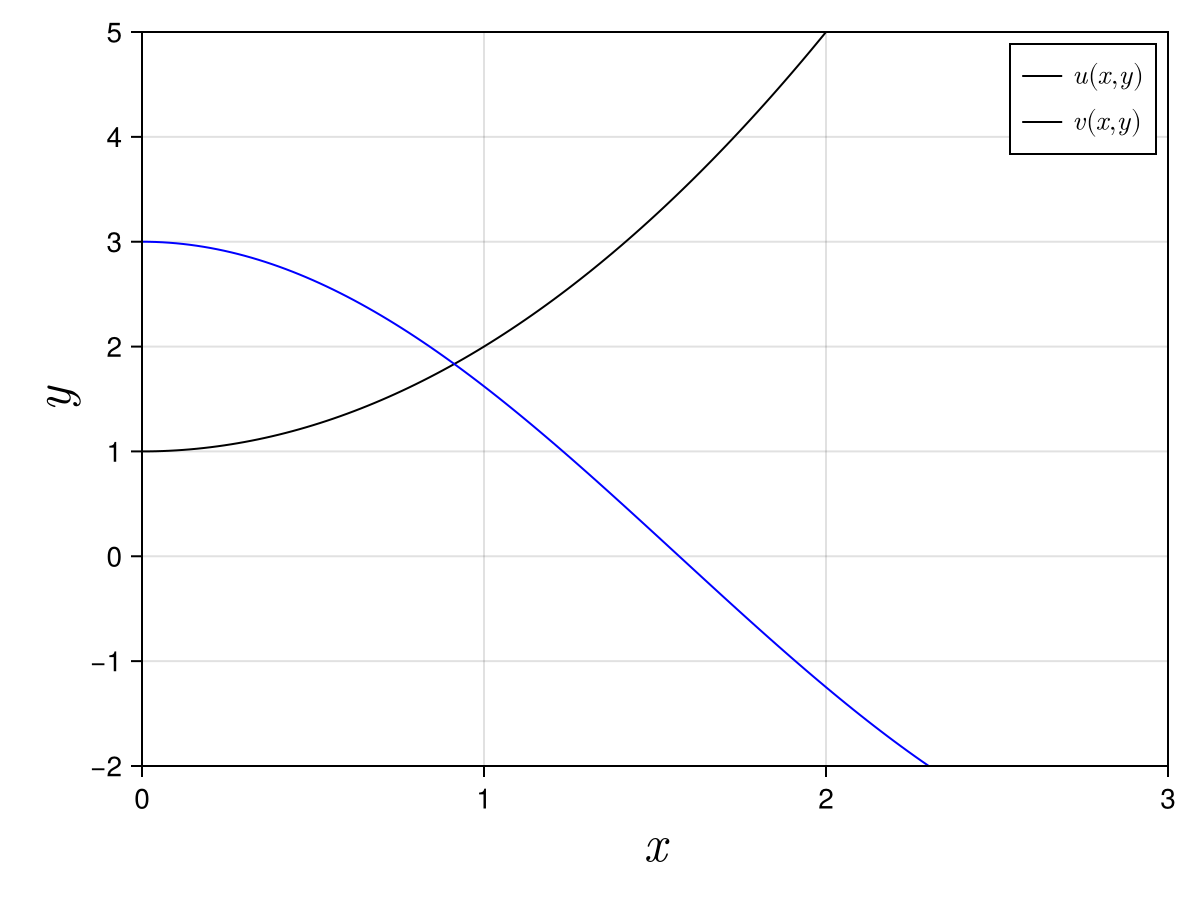

CairoMakie.Screen{IMAGE}


In [16]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    xlabelsize = 25, 
    ylabelsize = 25,
    limits=(0,3.0,-2.0,5.0))

contour!(ax,xrange,yrange,getindex.(functionToPlot,1);  levels = [0.0],color=:black, label=L"u(x,y)")
contour!(ax,xrange,yrange,getindex.(functionToPlot,2);  levels = [0.0],color=:blue, label=L"v(x,y)")

axislegend(ax, position = :rt) # Options: :rt, :lt, :lb, :rb, etc.

display(fig)

To solve this set of equations we can use Newton Raphson method.

We will now use julia's  `NonlinearSolve` library to solve the set of two equations

In [17]:
function FunctionToSolve(x)
    func=[x[1]^2-x[2]+1,3*cos(x[1])-x[2]]
    return func
end

FunctionToSolve (generic function with 1 method)

In [18]:
prob = NonlinearProblem((x,p)->FunctionToSolve(x),[1,1],[])
sol = NonlinearSolve.solve(prob)

retcode: Success
u: 2-element Vector{Float64}:
 0.913132000785916
 1.83381005085929

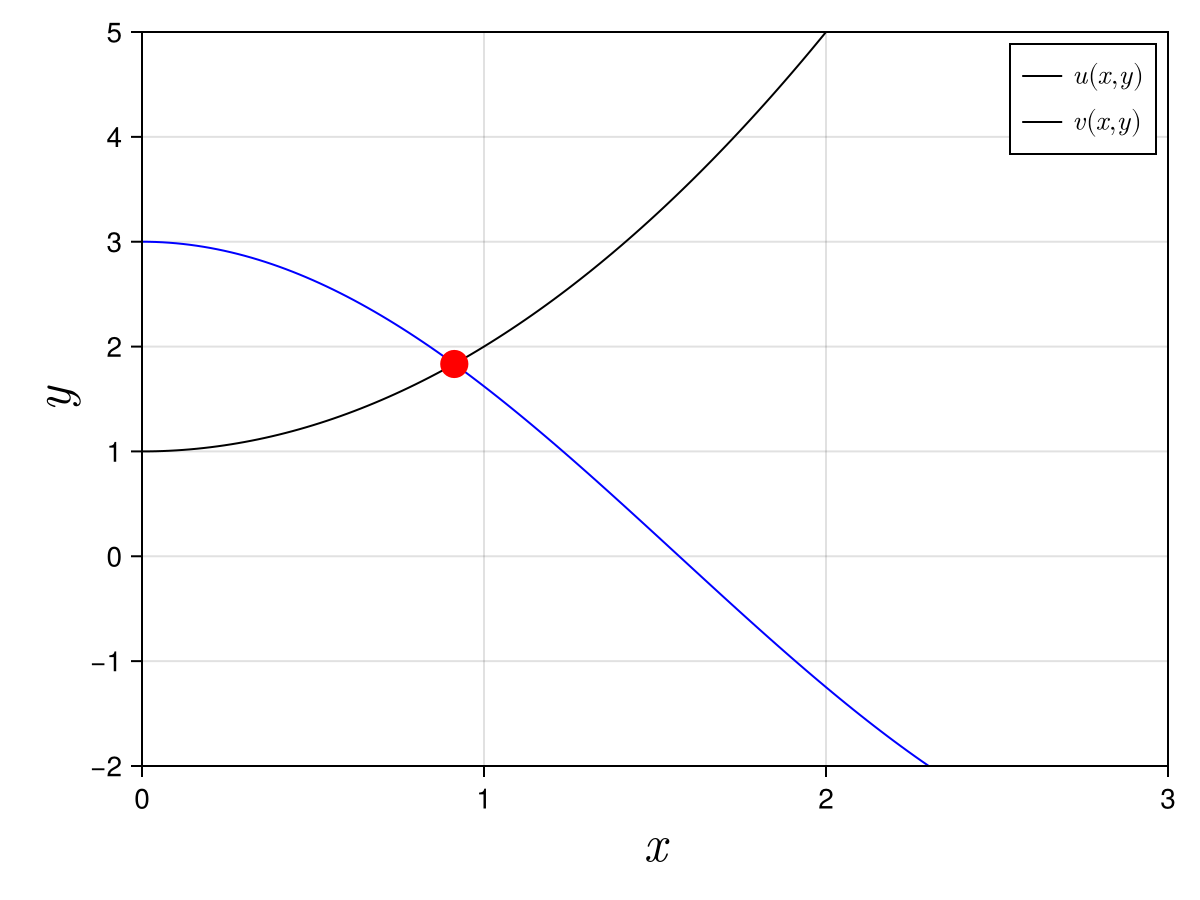

CairoMakie.Screen{IMAGE}


In [19]:
scatter!(ax,sol.u[1],sol.u[2];  color=:red,markersize=20)
display(fig)

---

**Class  Demo 03:**  Change my program above and find all the solutions to the following set of two equations

$x^2+y^2=1$

$4x^2+\frac{y^2}{4}=1$

---